In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

# pip install numpy pandas 
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

# pip install kagglehub
import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

# pip install matplotlib
import matplotlib.pyplot as plt

# pip install scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.svm import SVC
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, roc_auc_score
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression


# Titanic-Überlebensanalyse nach CRISP-DM

In [2]:
# Trainingsdatensatz einlesen
train_data = pd.read_csv("train.csv")
test_data = pd.read_csv("test.csv")

# Print Größe Trainingsdatensatz
print("Größe Trainingsdatensatz:", train_data.shape[0])
print("Größe Testdatensatz:", test_data.shape[0])

# Verhältnis Train/Test-Datensatz in Prozent
sum_train_test = train_data.shape[0] + test_data.shape[0]
print("Train/Test-Datensatz:", train_data.shape[0] / sum_train_test * 100, "% /", test_data.shape[0] / sum_train_test * 100, "%")


Größe Trainingsdatensatz: 891
Größe Testdatensatz: 418
Train/Test-Datensatz: 68.0672268907563 % / 31.932773109243694 %


## 1. Business Understanding

### 1.1 Problemstellung

Ziel des Projekts ist es, vorherzusagen, ob ein Passagier
die Titanic-Katastrophe überlebt hat.

### 1.2 Zielsetzung

Anhand von Passagiermerkmalen wie Geschlecht, Alter,
Passagierklasse, Fahrpreis und Familiengröße soll ein
Klassifikationsmodell erstellt werden.

### 1.3 Erfolgskriterien

Das Modell soll Überlebende und Nicht-Überlebende möglichst
zuverlässig unterscheiden.

Zur Bewertung werden verwendet:

- Accuracy
- Precision
- Recall
- F1-Score
- ROC-AUC
- Confusion Matrix

Da `Survived` nur die Werte 0 und 1 enthält, handelt es sich um ein Klassifikationsproblem. Deshalb werden logistische Regression oder Support Vector Machines verwendet und keine klassische lineare Regression.

## 2. Data Understanding

### 2.1 Datensatz

In [3]:
train_data.shape # (Anzahl_Zeilen: 891, Anzahl_Spalten: 12)

(891, 12)

In [4]:
# Check column types
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


Der Trainingsdatensatz enthält 891 Passagiere und folgende Merkmale:

| Merkmal | Beschreibung | Datentyp | Skalenniveau |
|---|---|---|---|
| `PassengerId` | Eindeutige Identifikationsnummer des Passagiers | Ganzzahl | Nominal |
| `Survived` | Gibt an, ob der Passagier überlebt hat: `0` = nein, `1` = ja | Binär | Nominal |
| `Pclass` | Passagierklasse: `1` = erste, `2` = zweite, `3` = dritte Klasse | Ganzzahl | Ordinal |
| `Name` | Vollständiger Name des Passagiers einschließlich Titel | Text | Nominal |
| `Sex` | Geschlecht des Passagiers: `male` oder `female` | Kategorisch | Nominal |
| `Age` | Alter des Passagiers in Jahren | Dezimalzahl | Metrisch, Verhältnisskala |
| `SibSp` | Anzahl der Geschwister oder Ehepartner an Bord | Ganzzahl | Metrisch, Verhältnisskala |
| `Parch` | Anzahl der Eltern oder Kinder an Bord | Ganzzahl | Metrisch, Verhältnisskala |
| `Ticket` | Ticketnummer des Passagiers | Text | Nominal |
| `Fare` | Gezahlter Fahrpreis | Dezimalzahl | Metrisch, Verhältnisskala |
| `Cabin` | Kabinennummer des Passagiers | Text | Nominal |
| `Embarked` | Einschiffungshafen: `C` = Cherbourg, `Q` = Queenstown, `S` = Southampton | Kategorisch | Nominal |

### 2.2 Zielvariable (Survived)


In [5]:
# Anzeige der Zielvariable: Survived (0 = No, 1 = Yes) im Trainingsdatensatz mit Anzahl der Überlebenden und Nicht-Überlebenden
train_data['Survived'].value_counts()

Survived
0    549
1    342
Name: count, dtype: int64

*549 Personen* haben nicht überlebt (Survived=0)
<!--  -->
*342 Personen* haben überlebt (Survived=1)


### 2.3 Erste Datenanalyse

Untersucht werden:

- Anzahl der Zeilen und Spalten
- Datentypen
- fehlende Werte
- statistische Kennzahlen
- Verteilung der Zielvariable
- mögliche Ausreißer
- Zusammenhänge zwischen Merkmalen und Überleben

In [6]:
# Anzahl der Zeilen und Spalten im Testdatensatz
train_data.shape # (Anzahl_Zeilen: 891, Anzahl_Spalten: 12)

(891, 12)

In [7]:
# Datentypen der Spalten im Trainingsdatensatz
train_data.dtypes

PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object

In [8]:
# Fehlende Werte in den Spalten des Trainingsdatensatzes
train_data.isna().sum().sort_values(ascending=False)

Cabin          687
Age            177
Embarked         2
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
SibSp            0
Parch            0
Ticket           0
Fare             0
dtype: int64

In [9]:
# Statistische Kennzahlen der Spalten im Trainingsdatensatz
train_data.drop(columns=["PassengerId", "Survived"]).describe().T

,count,mean,std,min,25%,50%,75%,max
Pclass,891.0,2.308642,0.836071,1.00,2.0000,3.0000,3.0,3.0000
Age,714.0,29.699118,14.526497,0.42,20.1250,28.0000,38.0,80.0000
SibSp,891.0,0.523008,1.102743,0.00,0.0000,0.0000,1.0,8.0000
Parch,891.0,0.381594,0.806057,0.00,0.0000,0.0000,0.0,6.0000
Fare,891.0,32.204208,49.693429,0.00,7.9104,14.4542,31.0,512.3292


In [10]:
# Verteilung der Zielvariable: Survived (0 = No, 1 = Yes) im Trainingsdatensatz
train_data['Survived'].value_counts(normalize=True)

Survived
0    0.616162
1    0.383838
Name: proportion, dtype: float64

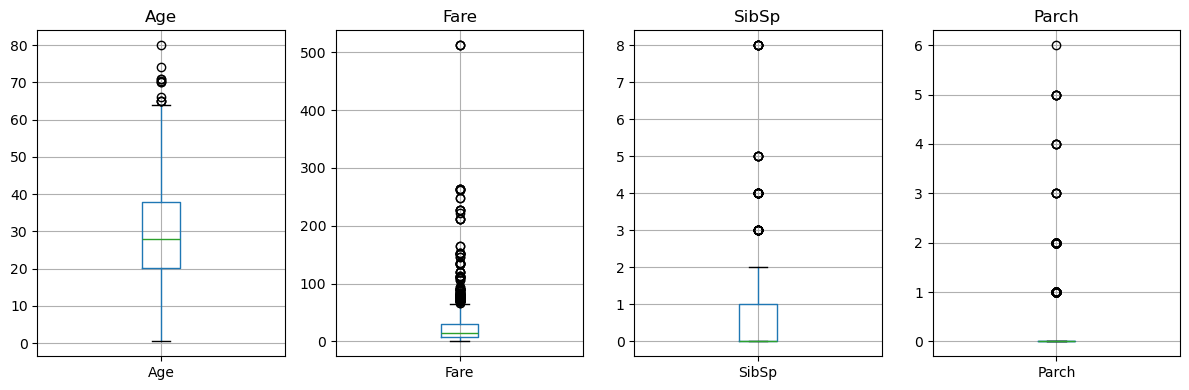

In [11]:
columns = ["Age", "Fare", "SibSp", "Parch"]

fig, axes = plt.subplots(1, 4, figsize=(12, 4))

for ax, column in zip(axes, columns):
    train_data.boxplot(column=column, ax=ax)
    ax.set_title(column)
    ax.set_xlabel("")

plt.tight_layout()
plt.show()

- **Age:** Das mittlere Alter beträgt etwa **29,7 Jahre**, der Median **28 Jahre**; die mittleren 50 % liegen zwischen **20,1 und 38 Jahren**, während einzelne hohe Alterswerte im Boxplot als Ausreißer erscheinen.
- **Fare:** Der durchschnittliche Fahrpreis beträgt **32,20**, der Median jedoch nur **14,45**; die mittleren 50 % liegen zwischen **7,91 und 31,00**, und viele hohe Preise bis **512,33** machen die Verteilung stark rechtsschief.
- **SibSp:** Die meisten Passagiere hatten keine Geschwister oder Ehepartner an Bord; der Median ist **0**, die mittleren 50 % liegen zwischen **0 und 1**, und Werte ab **3** erscheinen als Ausreißer.
- **Parch:** Mindestens 75 % der Passagiere hatten keine Eltern oder Kinder an Bord; deshalb liegen Median und beide Quartile bei **0**, die Box fällt zusammen und alle positiven Werte bis **6** erscheinen als Ausreißer.

### 2.4 Explorative Datenanalyse

#### 2.4.1 Gesamtüberlebensrate

In [12]:
# Survival balance
survival_balance = pd.DataFrame({
    "passengers": train_data["Survived"].value_counts(),
    "survival_rate": train_data["Survived"]
        .value_counts(normalize=True).mul(100).round(1)
}).rename(index={0: "Nicht überlebt", 1: "Überlebt"})

survival_balance
# 61.6% of passengers did not survive
# 38.4% of passengers survived

,passengers,survival_rate
Survived,,
Nicht überlebt,549,61.6
Überlebt,342,38.4


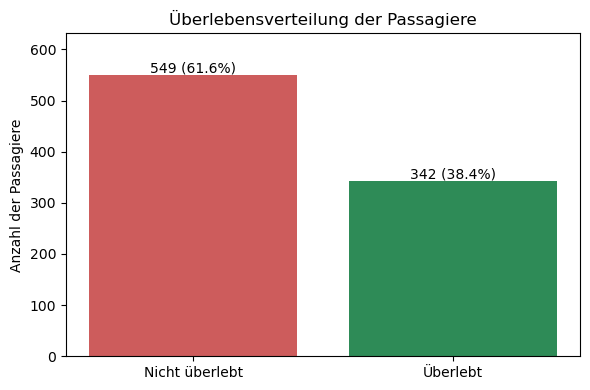

In [13]:
fig, ax = plt.subplots(figsize=(6, 4))

bars = ax.bar(
    survival_balance.index,
    survival_balance["passengers"],
    color=["indianred", "seagreen"]
)

for bar, count, rate in zip(
    bars,
    survival_balance["passengers"],
    survival_balance["survival_rate"]
):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{count} ({rate:.1f}%)",
        ha="center",
        va="bottom"
    )

ax.set_title("Überlebensverteilung der Passagiere")
ax.set_ylabel("Anzahl der Passagiere")
ax.set_ylim(0, survival_balance["passengers"].max() * 1.15)

plt.tight_layout()
plt.show()

#### 2.4.2 Überlebensrate nach Geschlecht

In [14]:
# Survival rate by gender
sex_survival = (
    train_data.groupby("Sex")["Survived"]
    .agg(passengers="count", survival_rate="mean")
)

sex_survival["survival_rate"] = (
    sex_survival["survival_rate"] * 100
).round(1)

sex_survival
# 74.2% of females survived
# 18.9% of males survived

,passengers,survival_rate
Sex,,
female,314,74.2
male,577,18.9


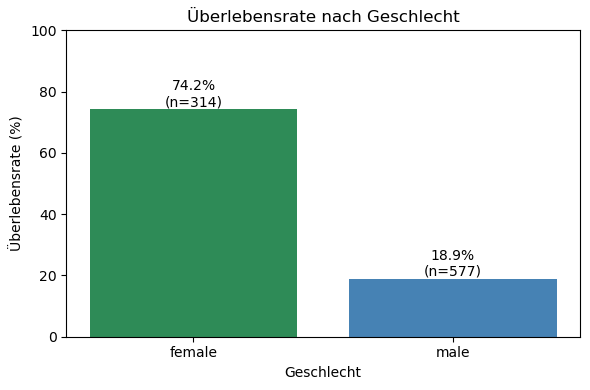

In [15]:
fig, ax = plt.subplots(figsize=(6, 4))

bars = ax.bar(
    sex_survival.index,
    sex_survival["survival_rate"],
    color=["seagreen", "steelblue"]
)

for bar, count, rate in zip(
    bars,
    sex_survival["passengers"],
    sex_survival["survival_rate"]
):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{rate:.1f}%\n(n={count})",
        ha="center",
        va="bottom"
    )

ax.set_title("Überlebensrate nach Geschlecht")
ax.set_xlabel("Geschlecht")
ax.set_ylabel("Überlebensrate (%)")
ax.set_ylim(0, 100)

plt.tight_layout()
plt.show()

#### 2.4.3 Überlebensrate nach Klasse

In [16]:
# Survival rate by class
class_survival = (
    train_data.groupby("Pclass")["Survived"]
    .agg(passengers="count", survival_rate="mean")
)

class_survival["survival_rate"] = (
    class_survival["survival_rate"] * 100
).round(1)

class_survival

,passengers,survival_rate
Pclass,,
1,216,63.0
2,184,47.3
3,491,24.2


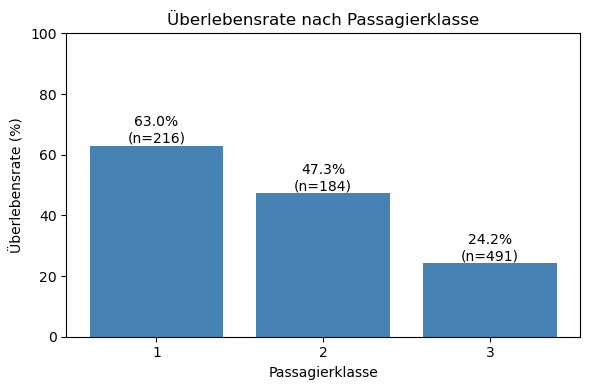

In [17]:
fig, ax = plt.subplots(figsize=(6, 4))

bars = ax.bar(
    class_survival.index.astype(str),
    class_survival["survival_rate"],
    color="steelblue"
)

for bar, count, rate in zip(
    bars,
    class_survival["passengers"],
    class_survival["survival_rate"]
):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{rate:.1f}%\n(n={count})",
        ha="center",
        va="bottom"
    )

ax.set_title("Überlebensrate nach Passagierklasse")
ax.set_xlabel("Passagierklasse")
ax.set_ylabel("Überlebensrate (%)")
ax.set_ylim(0, 100)

plt.tight_layout()
plt.show()

#### 2.4.4 Überlebensrate nach Altersgruppen

In [18]:
# Survival rate by age group
train_data['AgeGroup'] = pd.cut(train_data['Age'], bins=[0, 12, 18, 35, 60, 80], labels=['Child', 'Teenager', 'Adult', 'Middle-aged', 'Senior'])
train_data["AgeGroup"] = train_data["AgeGroup"].cat.add_categories("Unknown").fillna("Unknown")

age_survival = (
    train_data.groupby("AgeGroup", observed=True)["Survived"]
    .agg(passengers="count", survival_rate="mean")
)

age_survival["survival_rate"] = (
    age_survival["survival_rate"] * 100
).round(1)

age_survival
# 58.0% of children survived <-- höchste Überlebensrate
# 42.9% of teenagers survived
# 38.3% of adults survived
# 40.0% of middle-aged survived
# 22.7% of seniors survived <-- niedrigste Überlebensrate
# 29.4% of unknown age survived

,passengers,survival_rate
AgeGroup,,
Child,69,58.0
Teenager,70,42.9
Adult,358,38.3
Middle-aged,195,40.0
Senior,22,22.7
Unknown,177,29.4


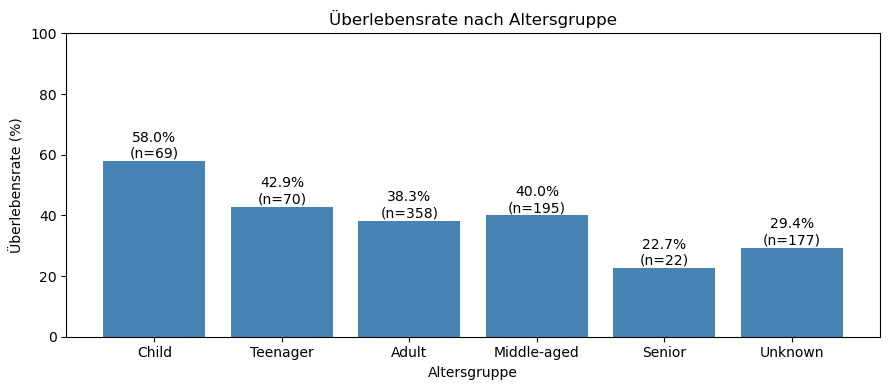

In [19]:
fig, ax = plt.subplots(figsize=(9, 4))

bars = ax.bar(
    age_survival.index.astype(str),
    age_survival["survival_rate"],
    color="steelblue"
)

for bar, count, rate in zip(
    bars,
    age_survival["passengers"],
    age_survival["survival_rate"]
):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{rate:.1f}%\n(n={count})",
        ha="center",
        va="bottom"
    )

ax.set_title("Überlebensrate nach Altersgruppe")
ax.set_xlabel("Altersgruppe")
ax.set_ylabel("Überlebensrate (%)")
ax.set_ylim(0, 100)

plt.tight_layout()
plt.show()

#### 2.4.5 Überlebensrate nach Title

In [20]:
# Survival rate by title
train_data["Title"] = train_data["Name"].str.extract(r",\s*([^.]*)\.", expand=False).str.strip()

title_survival = (
    train_data.groupby("Title")
    .agg(
        passengers=("Survived", "count"),
        survival_rate=("Survived", "mean")
    )
    .sort_values("passengers", ascending=False)
)

title_survival["survival_rate"] = (title_survival["survival_rate"] * 100).round(1)
title_survival # Mrs, Miss, Master, Mr and Others

,passengers,survival_rate
Title,,
Mr,517,15.7
Miss,182,69.8
Mrs,125,79.2
Master,40,57.5
Dr,7,42.9
Rev,6,0.0
Major,2,50.0
Col,2,50.0
Mlle,2,100.0


In [21]:
main_titles = ["Mrs", "Miss", "Master", "Mr"]
train_data["TitleGroup"] = train_data["Title"].where(train_data["Title"].isin(main_titles), "Rare Titles")

title_survival = train_data.groupby("TitleGroup").agg(
    passengers=("Survived", "count"),
    survival_rate=("Survived", "mean")
)

title_survival["survival_rate"] = title_survival["survival_rate"].mul(100).round(1)
title_survival = title_survival.sort_values(by="survival_rate", ascending=False)

title_survival
# 79,2% of Mrs survived <-- höchste Überlebensrate (verheiratete Frauen)
# 69.8% of Miss survived
# 57.5% of Master survived
# 44.4% of Rare Titles survived
# 15.7% of Mr survived <-- niedrigste Überlebensrate (Vgl.: 18.9% of males survived)

,passengers,survival_rate
TitleGroup,,
Mrs,125,79.2
Miss,182,69.8
Master,40,57.5
Rare Titles,27,44.4
Mr,517,15.7


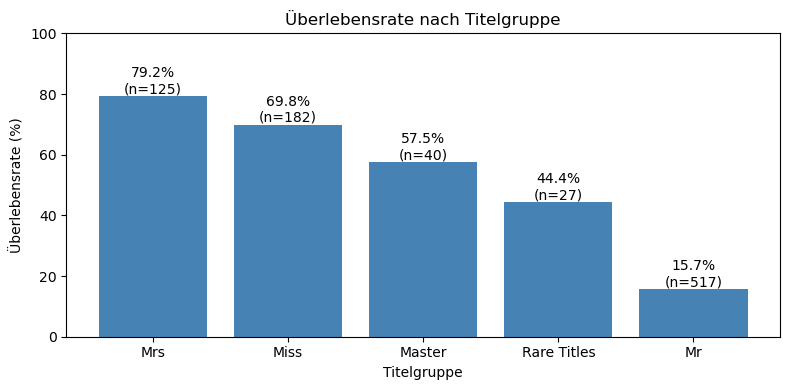

In [22]:
fig, ax = plt.subplots(figsize=(8, 4))

bars = ax.bar(
    title_survival.index,
    title_survival["survival_rate"],
    color="steelblue"
)

for bar, count, rate in zip(
    bars,
    title_survival["passengers"],
    title_survival["survival_rate"]
):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{rate:.1f}%\n(n={count})",
        ha="center",
        va="bottom"
    )

ax.set_title("Überlebensrate nach Titelgruppe")
ax.set_xlabel("Titelgruppe")
ax.set_ylabel("Überlebensrate (%)")
ax.set_ylim(0, 100)

plt.tight_layout()
plt.show()

#### 2.4.6 Überlebensrate nach Ticketpreis

In [23]:
# Survival rate by fare
train_data["FareGroup"] = pd.cut(
    train_data["Fare"],
    bins=[-float("inf"), 40, 80, float("inf")],
    labels=["0-40", "40-80", ">80"]
)

fare_survival = (
    train_data.groupby("FareGroup", observed=True)["Survived"]
    .agg(passengers="count", survival_rate="mean")
)

fare_survival["survival_rate"] = (
    fare_survival["survival_rate"] * 100
).round(1)

fare_survival
# 77% of passengers with fare >80 survived <-- höchste Überlebensrate
# 54.9% of passengers with fare 40-80 survived
# 32% of passengers with fare 0-40 survived

,passengers,survival_rate
FareGroup,,
0-40,715,32.0
40-80,102,54.9
>80,74,77.0


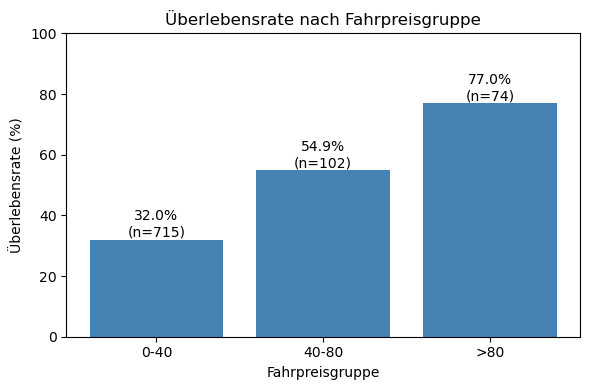

In [24]:
fig, ax = plt.subplots(figsize=(6, 4))

bars = ax.bar(
    fare_survival.index.astype(str),
    fare_survival["survival_rate"],
    color="steelblue"
)

for bar, count, rate in zip(
    bars,
    fare_survival["passengers"],
    fare_survival["survival_rate"]
):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{rate:.1f}%\n(n={count})",
        ha="center",
        va="bottom"
    )

ax.set_title("Überlebensrate nach Fahrpreisgruppe")
ax.set_xlabel("Fahrpreisgruppe")
ax.set_ylabel("Überlebensrate (%)")
ax.set_ylim(0, 100)

plt.tight_layout()
plt.show()

#### 2.4.7 Überlebensrate nach Familiengröße

In [25]:
# Anzahl an Passagieren mit/ohne Eltern/Kindern an Bord
train_data["Parch"].value_counts().sort_index()
##   0: 678
##   1: 118
## > 1: 95

Parch
0    678
1    118
2     80
3      5
4      4
5      5
6      1
Name: count, dtype: int64

In [26]:
# Familiengröße inklusive der Person selbst
train_data["FamilySize"] = train_data["SibSp"] + train_data["Parch"] + 1

In [27]:
train_data["FamilySize"] = train_data["SibSp"] + train_data["Parch"] + 1

train_data["FamilySizeGroup"] = pd.cut(
    train_data["FamilySize"],
    bins=[0, 1, 2, 3, 4, 5, float("inf")],
    labels=["1", "2", "3", "4", "5", ">5"]
)

family_survival = (
    train_data.groupby("FamilySizeGroup", observed=True)["Survived"]
    .agg(passengers="count", survival_rate="mean")
)

family_survival["survival_rate"] = (
    family_survival["survival_rate"] * 100
).round(1)

family_survival
# 4: 72.4 % <-- höchste Überlebensrate (nur 29 Passagiere)
# > 5; 14.9% <-- niedrigste Überlebensrate (nur 47 Passagiere)

,passengers,survival_rate
FamilySizeGroup,,
1,537,30.4
2,161,55.3
3,102,57.8
4,29,72.4
5,15,20.0
>5,47,14.9


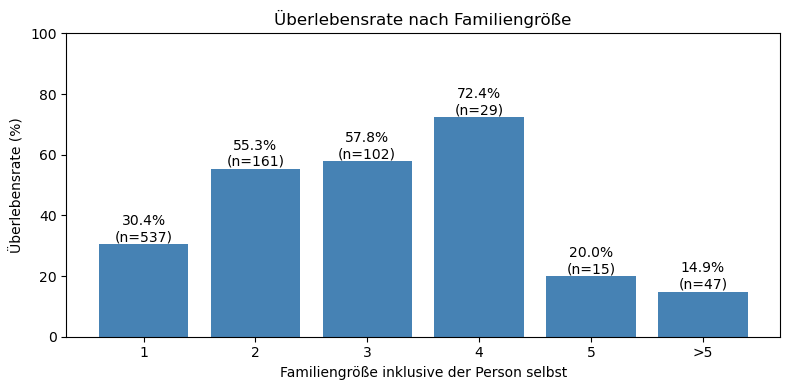

In [28]:
fig, ax = plt.subplots(figsize=(8, 4))

bars = ax.bar(
    family_survival.index.astype(str),
    family_survival["survival_rate"],
    color="steelblue"
)

for bar, count, rate in zip(
    bars,
    family_survival["passengers"],
    family_survival["survival_rate"]
):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{rate:.1f}%\n(n={count})",
        ha="center",
        va="bottom"
    )

ax.set_title("Überlebensrate nach Familiengröße")
ax.set_xlabel("Familiengröße inklusive der Person selbst")
ax.set_ylabel("Überlebensrate (%)")
ax.set_ylim(0, 100)

plt.tight_layout()
plt.show()

#### 2.4.8 Geschlecht und Klasse

In [29]:
sex_class_survival = train_data.groupby(["Sex", "Pclass"]).agg(
    passengers=("Survived", "count"),
    survival_rate=("Survived", "mean")
)

sex_class_survival["survival_rate"] = (
    sex_class_survival["survival_rate"].mul(100).round(1)
)

sex_class_survival

passengers  survival_rate
Sex    Pclass                           
female 1               94           96.8
       2               76           92.1
       3              144           50.0
male   1              122           36.9
       2              108           15.7
       3              347           13.5

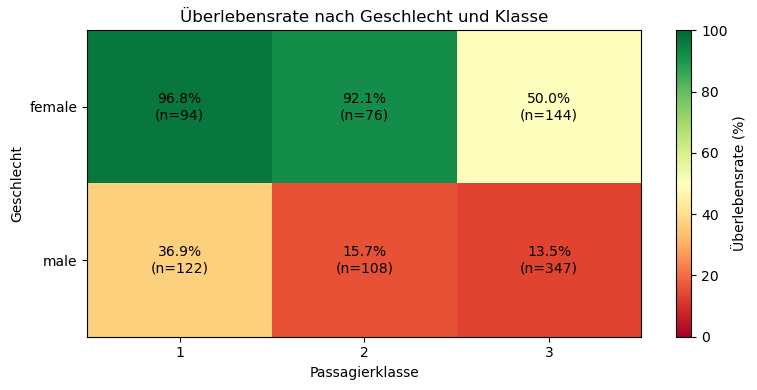

In [30]:
rates = sex_class_survival["survival_rate"].unstack("Pclass")
counts = sex_class_survival["passengers"].unstack("Pclass")

fig, ax = plt.subplots(figsize=(8, 4))
heatmap = ax.imshow(rates, cmap="RdYlGn", vmin=0, vmax=100, aspect="auto")

ax.set_xticks(range(len(rates.columns)), labels=rates.columns)
ax.set_yticks(range(len(rates.index)), labels=rates.index)
ax.set_xlabel("Passagierklasse")
ax.set_ylabel("Geschlecht")
ax.set_title("Überlebensrate nach Geschlecht und Klasse")

for row in range(len(rates.index)):
    for col in range(len(rates.columns)):
        rate = rates.iloc[row, col]
        count = counts.iloc[row, col]
        label = f"{rate:.1f}%\n(n={int(count)})" if pd.notna(rate) else "–"
        ax.text(col, row, label, ha="center", va="center")

fig.colorbar(heatmap, ax=ax, label="Überlebensrate (%)")
plt.tight_layout()
plt.show()

#### 2.4.9 Titel und Klasse

In [31]:
title_class_survival = train_data.groupby(["TitleGroup", "Pclass"]).agg(
    passengers=("Survived", "count"),
    survival_rate=("Survived", "mean")
)

title_class_survival["survival_rate"] = (
    title_class_survival["survival_rate"].mul(100).round(1)
)

title_class_survival

passengers  survival_rate
TitleGroup  Pclass                           
Master      1                3          100.0
            2                9          100.0
            3               28           39.3
Miss        1               46           95.7
            2               34           94.1
            3              102           50.0
Mr          1              107           34.6
            2               91            8.8
            3              319           11.3
Mrs         1               42           97.6
            2               41           90.2
            3               42           50.0
Rare Titles 1               18           61.1
            2                9           11.1

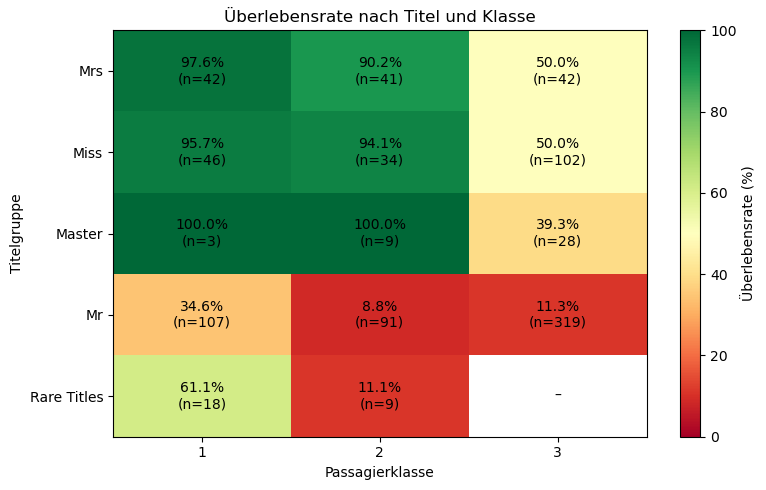

In [32]:
title_order = ["Mrs", "Miss", "Master", "Mr", "Rare Titles"]

rates = title_class_survival["survival_rate"].unstack("Pclass").reindex(title_order)
counts = title_class_survival["passengers"].unstack("Pclass").reindex(title_order)

fig, ax = plt.subplots(figsize=(8, 5))
heatmap = ax.imshow(rates, cmap="RdYlGn", vmin=0, vmax=100, aspect="auto")

ax.set_xticks(range(len(rates.columns)), labels=rates.columns)
ax.set_yticks(range(len(rates.index)), labels=rates.index)
ax.set_xlabel("Passagierklasse")
ax.set_ylabel("Titelgruppe")
ax.set_title("Überlebensrate nach Titel und Klasse")

for row in range(len(rates.index)):
    for col in range(len(rates.columns)):
        rate = rates.iloc[row, col]
        count = counts.iloc[row, col]
        label = f"{rate:.1f}%\n(n={int(count)})" if pd.notna(rate) else "–"
        ax.text(col, row, label, ha="center", va="center")

fig.colorbar(heatmap, ax=ax, label="Überlebensrate (%)")
plt.tight_layout()
plt.show()

#### 2.4.10 Geschlecht und Ticketpreis

In [33]:
sex_faregroup_survival = train_data.groupby(["Sex", "FareGroup"]).agg(
    passengers=("Survived", "count"),
    survival_rate=("Survived", "mean")
)

sex_faregroup_survival["survival_rate"] = (
    sex_faregroup_survival["survival_rate"].mul(100).round(1)
)

sex_faregroup_survival

C:\Users\turlacher\AppData\Local\Temp\ipykernel_38648\1350382022.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sex_faregroup_survival = train_data.groupby(["Sex", "FareGroup"]).agg(


passengers  survival_rate
Sex    FareGroup                           
female 0-40              221           66.5
       40-80              45           88.9
       >80                48           95.8
male   0-40              494           16.6
       40-80              57           28.1
       >80                26           42.3

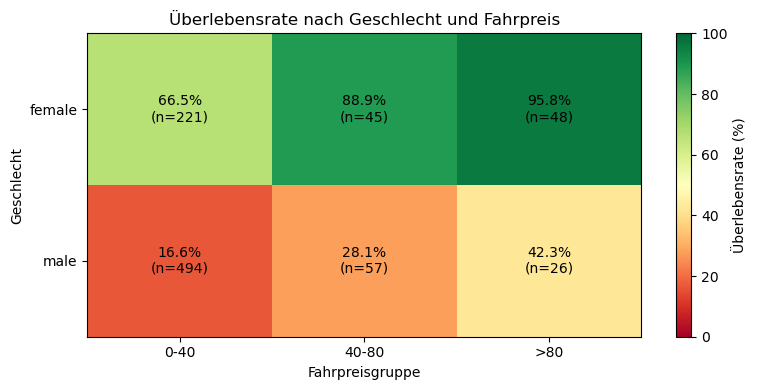

In [34]:
rates = sex_faregroup_survival["survival_rate"].unstack("FareGroup")
counts = sex_faregroup_survival["passengers"].unstack("FareGroup")

fig, ax = plt.subplots(figsize=(8, 4))
heatmap = ax.imshow(rates, cmap="RdYlGn", vmin=0, vmax=100, aspect="auto")

ax.set_xticks(range(len(rates.columns)), labels=rates.columns)
ax.set_yticks(range(len(rates.index)), labels=rates.index)
ax.set_xlabel("Fahrpreisgruppe")
ax.set_ylabel("Geschlecht")
ax.set_title("Überlebensrate nach Geschlecht und Fahrpreis")

for row in range(len(rates.index)):
    for col in range(len(rates.columns)):
        rate = rates.iloc[row, col]
        count = counts.iloc[row, col]
        label = f"{rate:.1f}%\n(n={int(count)})" if pd.notna(rate) else "–"
        ax.text(col, row, label, ha="center", va="center")

fig.colorbar(heatmap, ax=ax, label="Überlebensrate (%)")
plt.tight_layout()
plt.show()

#### 2.4.11 Klasse und Ticketpreis

In [35]:
class_faregroup_survival = train_data.groupby(["Pclass", "FareGroup"]).agg(
    passengers=("Survived", "count"),
    survival_rate=("Survived", "mean")
)

class_faregroup_survival["survival_rate"] = (
    class_faregroup_survival["survival_rate"].mul(100).round(1)
)

class_faregroup_survival

C:\Users\turlacher\AppData\Local\Temp\ipykernel_38648\161861542.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  class_faregroup_survival = train_data.groupby(["Pclass", "FareGroup"]).agg(


passengers  survival_rate
Pclass FareGroup                           
1      0-40               70           45.7
       40-80              72           65.3
       >80                74           77.0
2      0-40              174           47.7
       40-80              10           40.0
       >80                 0            NaN
3      0-40              471           24.2
       40-80              20           25.0
       >80                 0            NaN

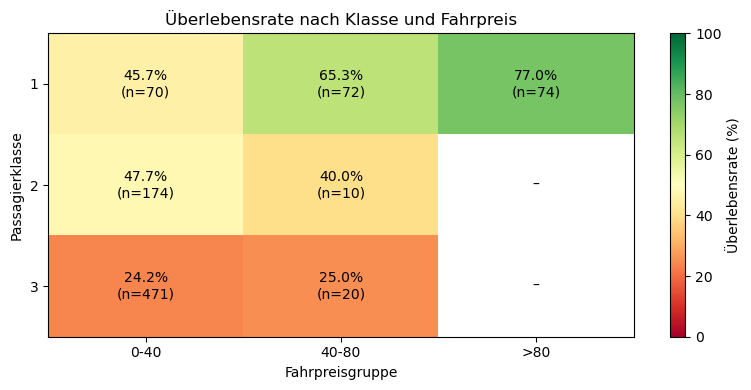

In [36]:
rates = class_faregroup_survival["survival_rate"].unstack("FareGroup")
counts = class_faregroup_survival["passengers"].unstack("FareGroup")

fig, ax = plt.subplots(figsize=(8, 4))
heatmap = ax.imshow(rates, cmap="RdYlGn", vmin=0, vmax=100, aspect="auto")

ax.set_xticks(range(len(rates.columns)), labels=rates.columns)
ax.set_yticks(range(len(rates.index)), labels=rates.index)
ax.set_xlabel("Fahrpreisgruppe")
ax.set_ylabel("Passagierklasse")
ax.set_title("Überlebensrate nach Klasse und Fahrpreis")

for row in range(len(rates.index)):
    for col in range(len(rates.columns)):
        rate = rates.iloc[row, col]
        count = counts.iloc[row, col]
        label = f"{rate:.1f}%\n(n={int(count)})" if pd.notna(rate) else "–"
        ax.text(col, row, label, ha="center", va="center")

fig.colorbar(heatmap, ax=ax, label="Überlebensrate (%)")
plt.tight_layout()
plt.show()

#### 2.4.12 Klasse und Familiengröße

In [37]:
class_family_survival = train_data.groupby(["Pclass", "FamilySizeGroup"]).agg(
    passengers=("Survived", "count"),
    survival_rate=("Survived", "mean")
)

class_family_survival["survival_rate"] = (
    class_family_survival["survival_rate"].mul(100).round(1)
)

class_family_survival

C:\Users\turlacher\AppData\Local\Temp\ipykernel_38648\152295004.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  class_family_survival = train_data.groupby(["Pclass", "FamilySizeGroup"]).agg(


passengers  survival_rate
Pclass FamilySizeGroup                           
1      1                       109           53.2
       2                        70           72.9
       3                        24           75.0
       4                         7           71.4
       5                         2          100.0
       >5                        4           50.0
2      1                       104           34.6
       2                        34           52.9
       3                        31           67.7
       4                        13           76.9
       5                         1          100.0
       >5                        1          100.0
3      1                       324           21.3
       2                        57           35.1
       3                        47           42.6
       4                         9           66.7
       5                        12            0.0
       >5                       42            9.5

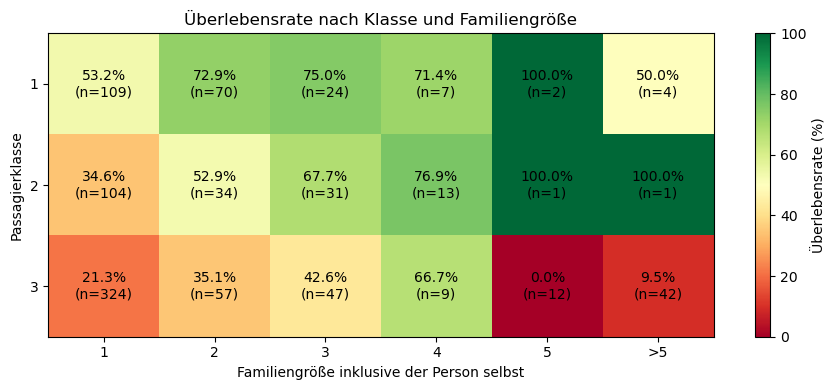

In [38]:
rates = class_family_survival["survival_rate"].unstack("FamilySizeGroup")
counts = class_family_survival["passengers"].unstack("FamilySizeGroup")

fig, ax = plt.subplots(figsize=(9, 4))
heatmap = ax.imshow(rates, cmap="RdYlGn", vmin=0, vmax=100, aspect="auto")

ax.set_xticks(range(len(rates.columns)), labels=rates.columns)
ax.set_yticks(range(len(rates.index)), labels=rates.index)
ax.set_xlabel("Familiengröße inklusive der Person selbst")
ax.set_ylabel("Passagierklasse")
ax.set_title("Überlebensrate nach Klasse und Familiengröße")

for row in range(len(rates.index)):
    for col in range(len(rates.columns)):
        rate = rates.iloc[row, col]
        count = counts.iloc[row, col]
        label = f"{rate:.1f}%\n(n={int(count)})" if pd.notna(rate) else "–"
        ax.text(col, row, label, ha="center", va="center")

fig.colorbar(heatmap, ax=ax, label="Überlebensrate (%)")
plt.tight_layout()
plt.show()

#### 2.4.13 Korrelation numerischer Features
- PassengerID können wir weglassen
- Geschlecht numerisch kodieren
- Pearson-Korrelation misst, wie stark zwei numerische Merkmale linear zusammenhängen
    - reagiert empfindlich auf Ausreißer
    - erkennt nicht-lineare Zusammenhänge schlecht

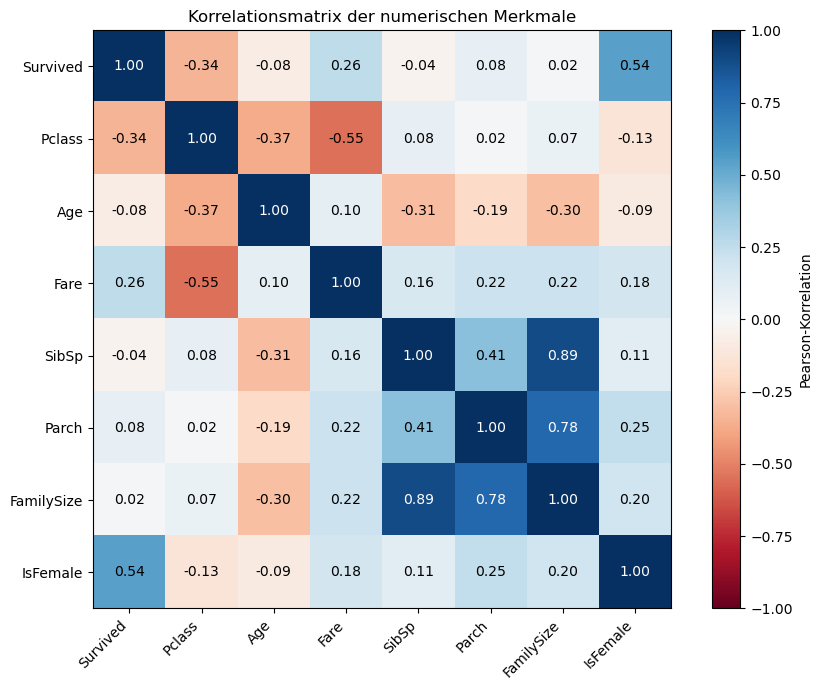

In [39]:
corr_data = train_data[
    ["Survived", "Pclass", "Age", "Fare", "SibSp", "Parch", "FamilySize"]
].copy()

corr_data["IsFemale"] = train_data["Sex"].map({"female": 1, "male": 0})
correlations = corr_data.corr()

fig, ax = plt.subplots(figsize=(9, 7))
heatmap = ax.imshow(correlations, cmap="RdBu", vmin=-1, vmax=1)

ax.set_xticks(
    range(len(correlations.columns)),
    labels=correlations.columns,
    rotation=45,
    ha="right"
)
ax.set_yticks(range(len(correlations.index)), labels=correlations.index)

for row in range(len(correlations.index)):
    for col in range(len(correlations.columns)):
        value = correlations.iloc[row, col]
        ax.text(
            col, row, f"{value:.2f}",
            ha="center", va="center",
            color="white" if abs(value) > 0.6 else "black"
        )

ax.set_title("Korrelationsmatrix der numerischen Merkmale")
fig.colorbar(heatmap, ax=ax, label="Pearson-Korrelation")
plt.tight_layout()
plt.show()

- IsFemale, Pclass und Fare mit den höchsten Korrelationswerten zu Survived
- Pclass-Fare: Passagiere mit höherer Klassennummer zahlten tendenziell weniger
- Pclass-Age: Passagiere mit höherer Klassennummer waren tendenziell jünger
- FamilySize berechnet sich aus SibSp und Parch, daher erwartbar höhere Werte

In [40]:
from scipy.stats import chi2_contingency

def chi_square_test(data, feature):
    table = pd.crosstab(data[feature], data["Survived"])
    chi2, p_value, dof, expected = chi2_contingency(table)

    print(f"{feature}:")
    print(f"Chi² = {chi2:.2f}, p = {p_value:.6g}")
    print("Signifikant:", p_value < 0.05)
    print()

for feature in ["Sex", "Pclass", "TitleGroup", "FareGroup", "FamilySizeGroup"]:
    chi_square_test(train_data, feature)

Sex:
Chi² = 260.72, p = 1.19736e-58
Signifikant: True

Pclass:
Chi² = 102.89, p = 4.54925e-23
Signifikant: True

TitleGroup:
Chi² = 283.31, p = 4.30504e-60
Signifikant: True

FareGroup:
Chi² = 70.70, p = 4.43541e-16
Signifikant: True

FamilySizeGroup:
Chi² = 77.71, p = 2.52364e-15
Signifikant: True



#### 2.4.14 Verteilung ausgewählter Merkmale

Die Histogramme zeigen die Verteilung der numerischen Merkmale `Age`
und `Fare`. Das Alter ist relativ breit verteilt, während der Fahrpreis
stark rechtsschief verteilt ist. Die meisten Passagiere bezahlten einen
niedrigen Fahrpreis, während wenige Passagiere sehr hohe Fahrpreise
bezahlten.

Die Balkendiagramme zeigen die Häufigkeiten diskreter und kategorialer
Merkmale. Die meisten Passagiere hatten keine Geschwister oder
Ehepartner und keine Eltern oder Kinder an Bord. Außerdem waren deutlich
mehr Männer als Frauen im Datensatz vertreten. Die dritte Passagierklasse
ist am häufigsten vertreten.

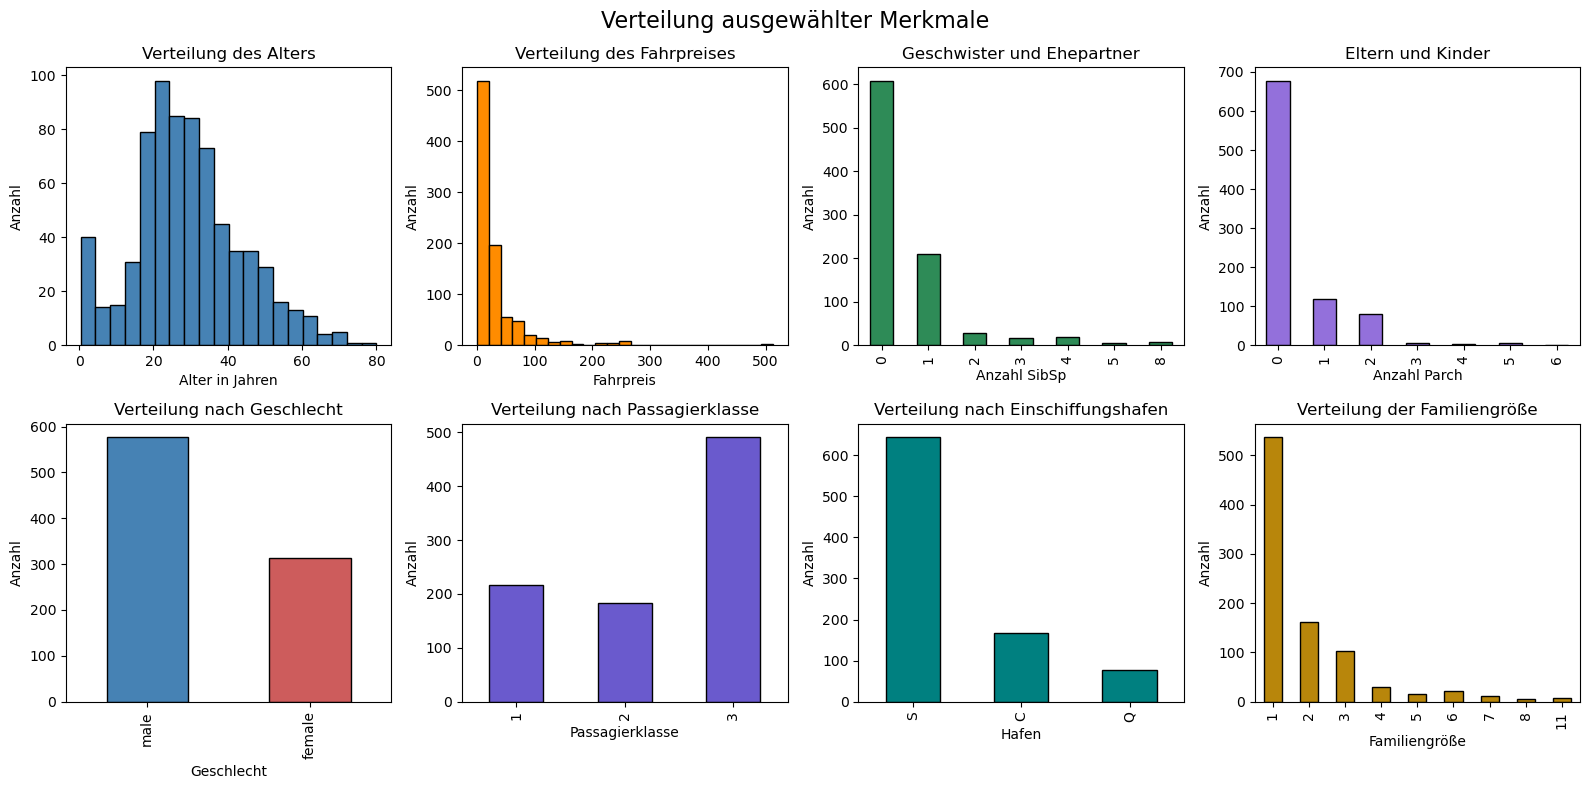

In [41]:
# Verteilung wichtiger Merkmale

fig, axes = plt.subplots(2, 4, figsize=(16, 8))

# Numerische Merkmale: Histogramme
axes[0, 0].hist(
    train_data["Age"].dropna(),
    bins=20,
    color="steelblue",
    edgecolor="black"
)
axes[0, 0].set_title("Verteilung des Alters")
axes[0, 0].set_xlabel("Alter in Jahren")
axes[0, 0].set_ylabel("Anzahl")

axes[0, 1].hist(
    train_data["Fare"].dropna(),
    bins=25,
    color="darkorange",
    edgecolor="black"
)
axes[0, 1].set_title("Verteilung des Fahrpreises")
axes[0, 1].set_xlabel("Fahrpreis")
axes[0, 1].set_ylabel("Anzahl")

# Diskrete Merkmale: Balkendiagramme
train_data["SibSp"].value_counts().sort_index().plot(
    kind="bar",
    ax=axes[0, 2],
    color="seagreen",
    edgecolor="black"
)
axes[0, 2].set_title("Geschwister und Ehepartner")
axes[0, 2].set_xlabel("Anzahl SibSp")
axes[0, 2].set_ylabel("Anzahl")

train_data["Parch"].value_counts().sort_index().plot(
    kind="bar",
    ax=axes[0, 3],
    color="mediumpurple",
    edgecolor="black"
)
axes[0, 3].set_title("Eltern und Kinder")
axes[0, 3].set_xlabel("Anzahl Parch")
axes[0, 3].set_ylabel("Anzahl")

train_data["Sex"].value_counts().plot(
    kind="bar",
    ax=axes[1, 0],
    color=["steelblue", "indianred"],
    edgecolor="black"
)
axes[1, 0].set_title("Verteilung nach Geschlecht")
axes[1, 0].set_xlabel("Geschlecht")
axes[1, 0].set_ylabel("Anzahl")

train_data["Pclass"].value_counts().sort_index().plot(
    kind="bar",
    ax=axes[1, 1],
    color="slateblue",
    edgecolor="black"
)
axes[1, 1].set_title("Verteilung nach Passagierklasse")
axes[1, 1].set_xlabel("Passagierklasse")
axes[1, 1].set_ylabel("Anzahl")

train_data["Embarked"].value_counts().plot(
    kind="bar",
    ax=axes[1, 2],
    color="teal",
    edgecolor="black"
)
axes[1, 2].set_title("Verteilung nach Einschiffungshafen")
axes[1, 2].set_xlabel("Hafen")
axes[1, 2].set_ylabel("Anzahl")

# Familiengröße berechnen und darstellen
family_size = train_data["SibSp"] + train_data["Parch"] + 1

family_size.value_counts().sort_index().plot(
    kind="bar",
    ax=axes[1, 3],
    color="darkgoldenrod",
    edgecolor="black"
)
axes[1, 3].set_title("Verteilung der Familiengröße")
axes[1, 3].set_xlabel("Familiengröße")
axes[1, 3].set_ylabel("Anzahl")

fig.suptitle("Verteilung ausgewählter Merkmale", fontsize=16)
plt.tight_layout()
plt.show()

#### 2.4.15 Zusammenfassung der explorativen Datenanalyse

- Der Datensatz enthält 577 Männer (64,8 %) und 314 Frauen (35,2 %).
- Insgesamt überlebten 342 Personen (38,4 %), während 549 Personen (61,6 %)
  nicht überlebten.
- Das Geschlecht zeigt den stärksten Zusammenhang mit dem Überleben:
  74,2 % der Frauen, aber nur 18,9 % der Männer überlebten.
- Die Passagierklasse ist ebenfalls sehr relevant:
  In der ersten Klasse überlebten 63,0 %, in der zweiten Klasse 47,3 %
  und in der dritten Klasse 24,2 %.
- Die Altersverteilung ist breit gestreut. Kinder hatten eine
  Überlebensrate von 58,0 %, Erwachsene von 38,3 % und Senioren von 22,7 %.
  Bei 177 Personen war das Alter unbekannt.
- Die Variable `Fare` ist stark rechtsschief verteilt. Die meisten
  Passagiere bezahlten einen niedrigen Fahrpreis, während wenige Passagiere
  sehr hohe Fahrpreise bezahlten.
- Die meisten Passagiere hatten keine Geschwister oder Ehepartner (`SibSp = 0`)
  und keine Eltern oder Kinder an Bord (`Parch = 0`).
- Die dritte Passagierklasse war am häufigsten vertreten.
- Der Titel zeigt deutliche Unterschiede bei der Überlebensrate:
  `Mrs` 79,2 %, `Miss` 69,8 %, `Master` 57,5 % und `Mr` 15,7 %.
  Der Titel ist jedoch stark mit dem Geschlecht verbunden und daher kein
  unabhängiger Einflussfaktor.
- Der Fahrpreis hängt deutlich mit der Überlebensrate zusammen:
  Bei einem Fahrpreis bis 40 überlebten 32,0 %, bei 40 bis 80 54,9 %
  und bei mehr als 80 77,0 %.
- Der Fahrpreis hängt außerdem mit der Passagierklasse zusammen.
  Höhere Fahrpreise wurden insbesondere in höheren Klassen bezahlt.
- Die Familiengröße zeigt keinen einfachen linearen Zusammenhang:
  Einzelreisende hatten eine Überlebensrate von 30,4 %, Familien mit vier
  Personen 72,4 %, Familien mit fünf Personen jedoch nur 20,0 %.
  Sehr große Familien mit mehr als fünf Personen hatten eine
  Überlebensrate von 14,9 %. Die kleinen Gruppengrößen müssen dabei
  berücksichtigt werden.
- Die Korrelationsmatrix bestätigt vor allem den Zusammenhang zwischen
  `Survived` und `IsFemale` (r = 0,54), `Pclass` (r = -0,34) und `Fare`
  (r = 0,26). Die Korrelation zwischen `FamilySize` und `Survived` ist
  dagegen sehr gering (r = 0,02).
- Die Verteilungen, gruppierten Überlebensraten und Korrelationswerte
  liefern wichtige Hinweise für die Modellierung. Sie beweisen jedoch
  keine kausalen Zusammenhänge.

**Statistische Signifikanz**

Für kategoriale Merkmale wie `Sex`, `Pclass`, `TitleGroup` und `FareGroup`
ist ein Chi-Quadrat-Test geeignet.

Die Unterschiede nach Geschlecht und Passagierklasse sind statistisch
signifikant (p < 0,001). Auch die Unterschiede nach Titel und
Fahrpreisgruppe sind voraussichtlich signifikant (p < 0,001). Die
Altersgruppen sollten separat getestet werden, wobei die 177 fehlenden
Alterswerte berücksichtigt werden müssen.

Statistische Signifikanz bedeutet nicht automatisch, dass ein Merkmal
kausal für das Überleben verantwortlich ist. Außerdem hängen Titel und
Fahrpreis teilweise mit Geschlecht beziehungsweise Passagierklasse
zusammen.

Für die weitere Modellierung werden insbesondere `Sex`, `Pclass`, `Age`,
`Fare`, `FamilySize` und gegebenenfalls `TitleGroup` berücksichtigt.

### 2.5 TODO Erweiterte Explorative Datenanalyse ?!?

####  2.5.1 TODO K-Means Clustering ?!?


## 3. Data Preparation

### 3.1 Entfernen ungeeigneter Merkmale

`PassengerId` wird nicht als Prädiktor verwendet, da es nur
eine Identifikationsnummer ist.

`Name`, `Ticket` und `Cabin` werden zunächst nicht direkt
verwendet, da sie viele unterschiedliche Ausprägungen oder
fehlende Werte enthalten.

In [42]:
# PassengerId wird nicht für die Modellierung benötigt, daher entfernen wir diese Spalte aus den Trainings- und Testdatensätzen.
train_data = train_data.drop(columns=["PassengerId"])
test_data = test_data.drop(columns=["PassengerId"])

# Merkmale und Zielvariable
data = train_data.copy()

numeric_features = ["Age", "Fare", "FamilySize"]
categorical_features = ["Sex", "Pclass", "Embarked"]

### 3.2 Umgang mit fehlenden Werten

- Fehlende Werte in `Age` werden durch den Median ersetzt.
- Fehlende Werte in `Embarked` werden durch die häufigste
  Kategorie ersetzt.
- `Cabin` wird wegen des hohen Anteils fehlender Werte zunächst
  nicht verwendet.

In [43]:
# Fehlende Werte ersetzen und numerische Merkmale skalieren
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

### 3.3 Kodierung kategorialer Merkmale
Die Merkmale Sex, Pclass und Embarked werden mittels
One-Hot-Encoding in numerische Variablen umgewandelt.

In [44]:
# Fehlende Kategorien ersetzen und Kategorien codieren
categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

### 3.4 Skalierung numerischer Merkmale
Die numerischen Merkmale Age, Fare und FamilySize werden
standardisiert.

### 3.5 Aufteilung der Daten
Die Daten werden in Trainings- und Validierungsdaten aufgeteilt.
Dabei wird durch stratify=y das Verhältnis von Überlebenden und
Nicht-Überlebenden beibehalten.


In [45]:
X = data[numeric_features + categorical_features]
y = data["Survived"]

# 80 % Training, 20 % Validierung (179 Passagiere, davon 110 Nichtüberlebende und 69 Überlebende)
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
# Anzahl der Überlebenden und Nicht-Überlebenden im Trainingsdatensatz
print(f"Anzahl der Überlebenden und Nicht-Überlebenden im Trainingsdatensatz:\n {y_train.value_counts()}")
print(f"\nAnzahl der Überlebenden und Nicht-Überlebenden im Validierungsdatensatz:\n {y_val.value_counts()}")

Anzahl der Überlebenden und Nicht-Überlebenden im Trainingsdatensatz:
 Survived
0    439
1    273
Name: count, dtype: int64

Anzahl der Überlebenden und Nicht-Überlebenden im Validierungsdatensatz:
 Survived
0    110
1     69
Name: count, dtype: int64


### 3.6 PreProcessing

In [46]:
preprocessing = ColumnTransformer([
    ("numeric", numeric_pipeline, numeric_features),
    ("categorical", categorical_pipeline, categorical_features)
])

## 4. Modelling

### 4.1 Logistische Regression

Die logistische Regression wird als erstes Klassifikationsmodell
eingesetzt. Sie berechnet für jede Person die Wahrscheinlichkeit,
dass sie überlebt hat.

Da `Survived` die binären Werte `0` und `1` enthält, wird die
logistische Funktion verwendet. Wahrscheinlichkeiten ab 0,5 werden als
Überleben (`1`) und Wahrscheinlichkeiten unter 0,5 als Nicht-Überleben
(`0`) klassifiziert.

Die Vorverarbeitung wird gemeinsam mit dem Modell in einer Pipeline
durchgeführt. Fehlende numerische Werte werden durch den Median ersetzt,
fehlende kategoriale Werte durch die häufigste Kategorie. Anschließend
werden numerische Merkmale standardisiert und kategoriale Merkmale mittels
One-Hot-Encoding codiert.

Die Vorverarbeitung wird ausschließlich anhand der Trainingsdaten
gelernt. Dadurch wird verhindert, dass Informationen aus den
Validierungsdaten in das Training einfließen.

Als Startwert wird `C=1.0` verwendet. Dieser Parameter steuert die Stärke
der Regularisierung. Die Modellleistung wird anhand von Accuracy,
Precision, Recall, F1-Score, ROC-AUC und der Confusion Matrix bewertet.



Logistische Regression
                precision    recall  f1-score   support

Nicht überlebt       0.81      0.88      0.84       110
      Überlebt       0.78      0.67      0.72        69

      accuracy                           0.80       179
     macro avg       0.79      0.77      0.78       179
  weighted avg       0.80      0.80      0.80       179

ROC-AUC: 0.839


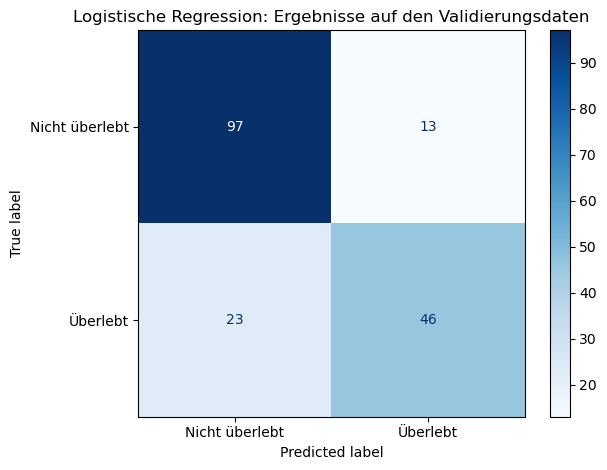

In [47]:
# Logistische Regression mit der bestehenden Vorverarbeitung
logistic_model = Pipeline([
    ("preprocessing", preprocessing),
    (
        "logistic_regression",
        LogisticRegression(
            C=1.0,
            max_iter=1000,
            solver="lbfgs"
        )
    )
])

# Modell nur auf den Trainingsdaten trainieren
logistic_model.fit(X_train, y_train)

# Vorhersagen für die Validierungsdaten
logistic_predictions = logistic_model.predict(X_val)

# Überlebenswahrscheinlichkeiten für ROC-AUC
logistic_probabilities = logistic_model.predict_proba(X_val)[:, 1]

print("Logistische Regression")
print(
    classification_report(
        y_val,
        logistic_predictions,
        target_names=["Nicht überlebt", "Überlebt"],
        zero_division=0
    )
)

print(
    "ROC-AUC:",
    round(roc_auc_score(y_val, logistic_probabilities), 3)
)

ConfusionMatrixDisplay.from_predictions(
    y_val,
    logistic_predictions,
    display_labels=["Nicht überlebt", "Überlebt"],
    cmap="Blues"
)

plt.title("Logistische Regression: Ergebnisse auf den Validierungsdaten")
plt.tight_layout()
plt.show()

### 4.2 Support Vector Machine (linear)

Die lineare SVM lernt auf den Trainingsdaten eine gerade Trennfläche im mehrdimensionalen Merkmalsraum. 
Sie versucht, zwischen den beiden Gruppen einen möglichst breiten Abstand, die Trennmarge, zu schaffen. 
Besonders entscheidend sind die Support-Vektoren (Personen im Trainingsdatensatz, die an der Grenze liegen oder die Marge verletzen).

In [48]:
# Lineare SVM
svm_model = Pipeline([
    ("preprocessing", preprocessing),
    ("svm", SVC(kernel="linear", C=1))
])

svm_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessing', ...), ('svm', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different tran

C bestimmt, wie stark die SVM Trainingsfehler bestraft:
- Kleines C: erlaubt mehr Fehler und bevorzugt eine größere Trennmarge. Mehr Trainingsfehler werden zugelassen.
- Großes C: versucht stärker, Trainingsfehler zu vermeiden; kann Overfitting begünstigen.

                precision    recall  f1-score   support

Nicht überlebt       0.80      0.85      0.82       110
      Überlebt       0.74      0.65      0.69        69

      accuracy                           0.78       179
     macro avg       0.77      0.75      0.76       179
  weighted avg       0.77      0.78      0.77       179

ROC-AUC: 0.806


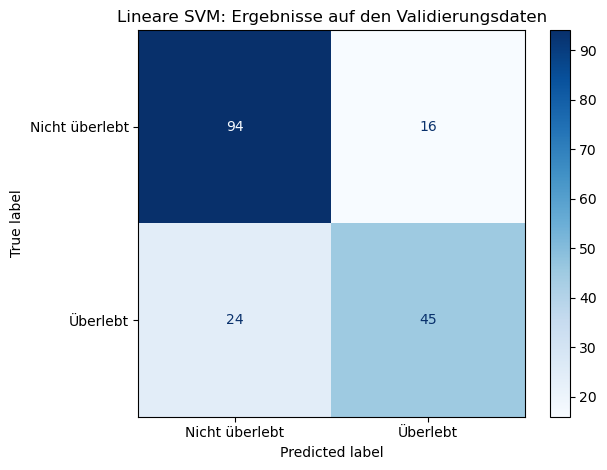

In [49]:
# Bewertung auf den Validierungsdaten
predictions = svm_model.predict(X_val)
scores = svm_model.decision_function(X_val)

print(classification_report(
    y_val,
    predictions,
    target_names=["Nicht überlebt", "Überlebt"],
    zero_division=0
))
print("ROC-AUC:", round(roc_auc_score(y_val, scores), 3))

ConfusionMatrixDisplay.from_predictions(
    y_val,
    predictions,
    display_labels=["Nicht überlebt", "Überlebt"],
    cmap="Blues"
)
plt.title("Lineare SVM: Ergebnisse auf den Validierungsdaten")
plt.tight_layout()
plt.show()

Mit 0.85 im Recall bei den Nicht-Überlebenden sagt das Modell diese Gruppe zuverlässiger voraus, als mit 0.65 in der Überlebenden-Gruppe.

                precision    recall  f1-score   support

Nicht überlebt       0.80      0.85      0.83       110
      Überlebt       0.74      0.67      0.70        69

      accuracy                           0.78       179
     macro avg       0.77      0.76      0.77       179
  weighted avg       0.78      0.78      0.78       179

ROC-AUC: 0.836


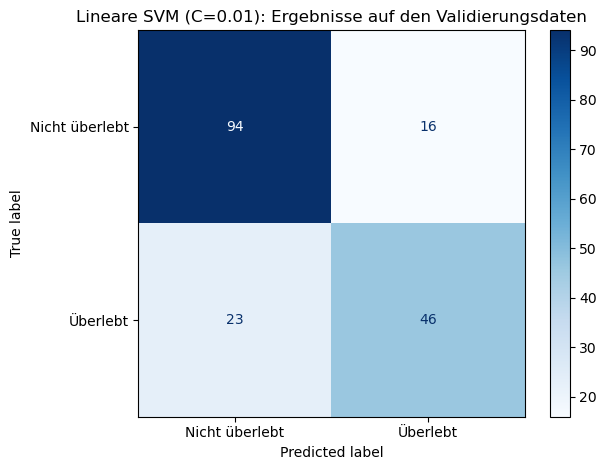

In [50]:
## C 0.01
# Lineare SVM
svm_model_C0_01 = Pipeline([
    ("preprocessing", preprocessing),
    ("svm", SVC(kernel="linear", C=0.01))
])

svm_model_C0_01.fit(X_train, y_train)

# Bewertung auf den Validierungsdaten
predictions = svm_model_C0_01.predict(X_val)
scores = svm_model_C0_01.decision_function(X_val)

print(classification_report(
    y_val,
    predictions,
    target_names=["Nicht überlebt", "Überlebt"],
    zero_division=0
))
print("ROC-AUC:", round(roc_auc_score(y_val, scores), 3))

ConfusionMatrixDisplay.from_predictions(
    y_val,
    predictions,
    display_labels=["Nicht überlebt", "Überlebt"],
    cmap="Blues"
)
plt.title("Lineare SVM (C=0.01): Ergebnisse auf den Validierungsdaten")
plt.tight_layout()
plt.show()

                precision    recall  f1-score   support

Nicht überlebt       0.80      0.85      0.82       110
      Überlebt       0.74      0.65      0.69        69

      accuracy                           0.78       179
     macro avg       0.77      0.75      0.76       179
  weighted avg       0.77      0.78      0.77       179

ROC-AUC: 0.796


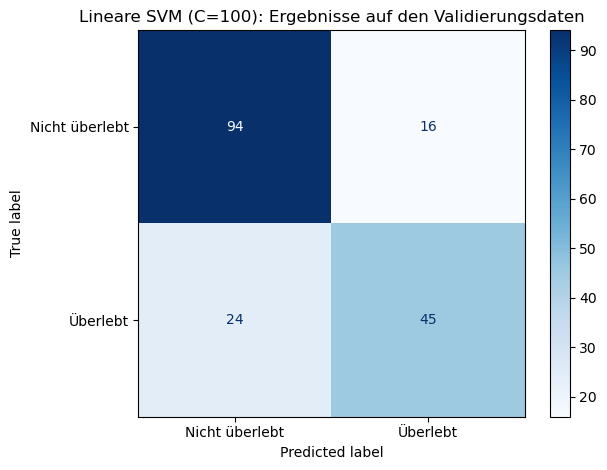

In [51]:
## C 100
# Lineare SVM
svm_model_C100 = Pipeline([
    ("preprocessing", preprocessing),
    ("svm", SVC(kernel="linear", C=100))
])

svm_model_C100.fit(X_train, y_train)

# Bewertung auf den Validierungsdaten
predictions = svm_model_C100.predict(X_val)
scores = svm_model_C100.decision_function(X_val)

print(classification_report(
    y_val,
    predictions,
    target_names=["Nicht überlebt", "Überlebt"],
    zero_division=0
))
print("ROC-AUC:", round(roc_auc_score(y_val, scores), 3))

ConfusionMatrixDisplay.from_predictions(
    y_val,
    predictions,
    display_labels=["Nicht überlebt", "Überlebt"],
    cmap="Blues"
)
plt.title("Lineare SVM (C=100): Ergebnisse auf den Validierungsdaten")
plt.tight_layout()
plt.show()

#### 4.2.1 SVM mit RBF-Kernel

                precision    recall  f1-score   support

Nicht überlebt       0.80      0.94      0.86       110
      Überlebt       0.86      0.62      0.72        69

      accuracy                           0.82       179
     macro avg       0.83      0.78      0.79       179
  weighted avg       0.82      0.82      0.81       179

ROC-AUC: 0.836


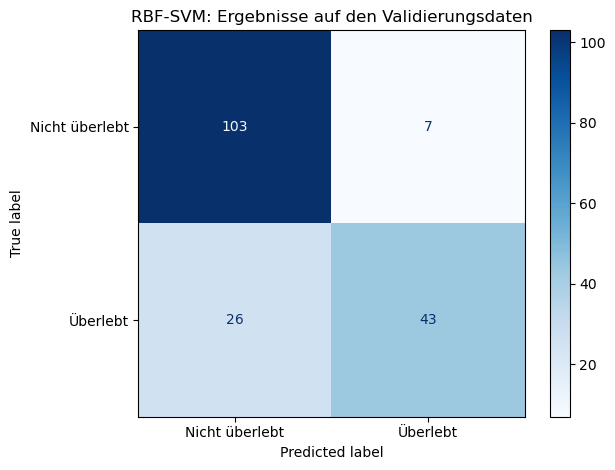

In [52]:
from sklearn.base import clone

# Vorverarbeitung übernehmen und eine neue SVM trainieren
rbf_model = clone(svm_model).set_params(
    svm__kernel="rbf",
    svm__C=1,
    svm__gamma="scale"
)

rbf_model.fit(X_train, y_train)

# Bewertung auf derselben Datenaufteilung
rbf_predictions = rbf_model.predict(X_val)
rbf_scores = rbf_model.decision_function(X_val)

print(classification_report(
    y_val,
    rbf_predictions,
    target_names=["Nicht überlebt", "Überlebt"],
    zero_division=0
))
print("ROC-AUC:", round(roc_auc_score(y_val, rbf_scores), 3))

ConfusionMatrixDisplay.from_predictions(
    y_val,
    rbf_predictions,
    display_labels=["Nicht überlebt", "Überlebt"],
    cmap="Blues"
)
plt.title("RBF-SVM: Ergebnisse auf den Validierungsdaten")
plt.tight_layout()
plt.show()

#### 4.2.2 Zusammenfassung Vorgehen bei der SVM
Ziel ist es, anhand der Passagiermerkmale vorherzusagen, ob eine Person das Titanic-Unglück überlebt. Als Eingangsmerkmale verwenden wir Alter, Fahrpreis, Familiengröße, Geschlecht, Passagierklasse und Einstiegshafen (kann evtl. entfernt werden - wurde in der EDA nicht näher betrachtet). Die Familiengröße berechnen wir aus der Anzahl der Geschwister beziehungsweise Ehepartner und Eltern beziehungsweise Kinder an Bord, einschließlich der Person selbst.

Wir teilen die 891 Datensätze mit bekannten Überlebensinformationen in 80 % Trainingsdaten und 20 % Validierungsdaten auf. Die Aufteilung erfolgt reproduzierbar mit random_state=42 und unter Beibehaltung der Klassenanteile.

Die Vorverarbeitung wird gemeinsam mit der SVM in einer Pipeline umgesetzt. Fehlende numerische Werte ersetzen wir durch den Median, fehlende kategoriale Werte durch die häufigste Kategorie. Numerische Merkmale werden standardisiert und kategoriale Merkmale mittels One-Hot-Encoding codiert. Sämtliche Vorverarbeitungsschritte werden ausschließlich anhand der Trainingsdaten gelernt.

### 4.3 Random Forrest - TODO Hansi

### 4.4 Gradient Boosting (XGBoost/LightGBM) - TODO Patrik

## 5 Evaluation - TODO

### 5.1 Bewertung der Modelle - TODO

Die Modelle werden auf den Validierungsdaten bewertet.

Verglichen werden:

- Accuracy
- Precision
- Recall
- F1-Score
- ROC-AUC
- Confusion Matrix

### 5.2 Interpretation der Ergebnisse - TODO

Besonders wichtig ist der Vergleich des Recalls:

Wie viele tatsächliche Überlebende werden erkannt?
Wie viele tatsächliche Nicht-Überlebende werden erkannt?
Die Ergebnisse werden für jedes Modell verglichen und
interpretiert.

### 5.4 Auswahl des besten Modells - TODO
Das Modell mit der besten Kombination aus F1-Score,
ROC-AUC und ausgewogenem Recall wird als bevorzugtes Modell
ausgewählt.

### 5.5 Fazit - TODO

## 6 Deployment - Wird nicht umgesetzt